### Q4(a) — Use Otsu Thresholding to obtain foreground mask and report threshold

Q4(a) - Otsu Threshold Value: 99.0


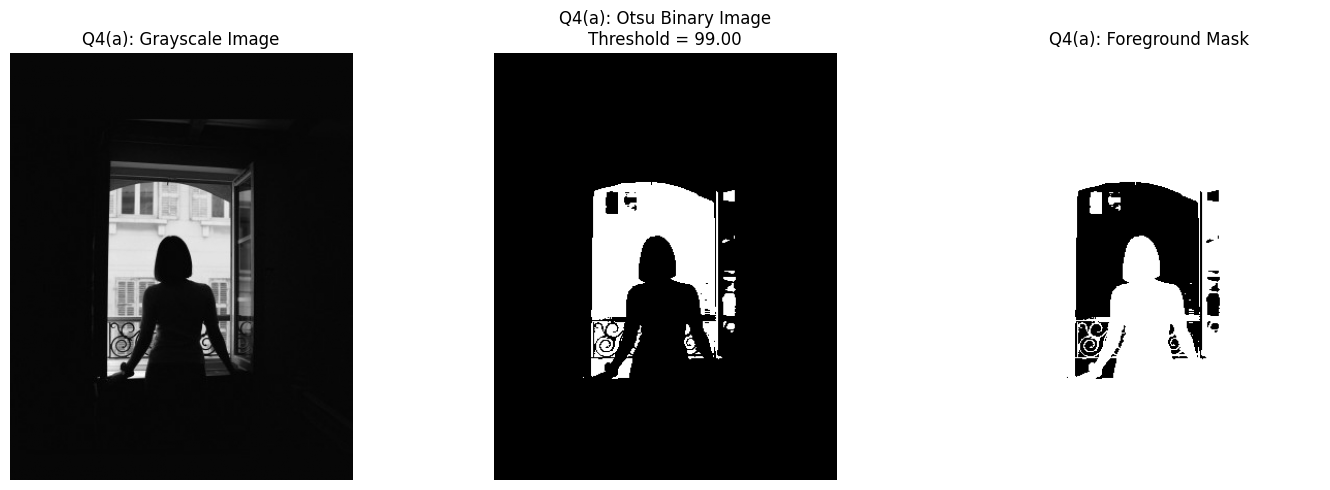

In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Q4(a) and Q4(b)
# Image: woman standing in front of an open door
# -------------------------------

# Load image
img = cv.imread('women_standing_front_open.jpg')

if img is None:
    raise FileNotFoundError("Image not found. Check the file path.")

# Convert to grayscale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# ===============================
# Q4(a) - Otsu Thresholding
# ===============================

# Apply Otsu thresholding
threshold_value, binary_img = cv.threshold(
    img_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
)

print("Q4(a) - Otsu Threshold Value:", threshold_value)

# Invert because foreground (woman + room) is dark
foreground_mask = cv.bitwise_not(binary_img)

# Display Q4(a) results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Q4(a): Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_img, cmap='gray')
plt.title(f'Q4(a): Otsu Binary Image\nThreshold = {threshold_value:.2f}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(foreground_mask, cmap='gray')
plt.title('Q4(a): Foreground Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

#### Q4(b)

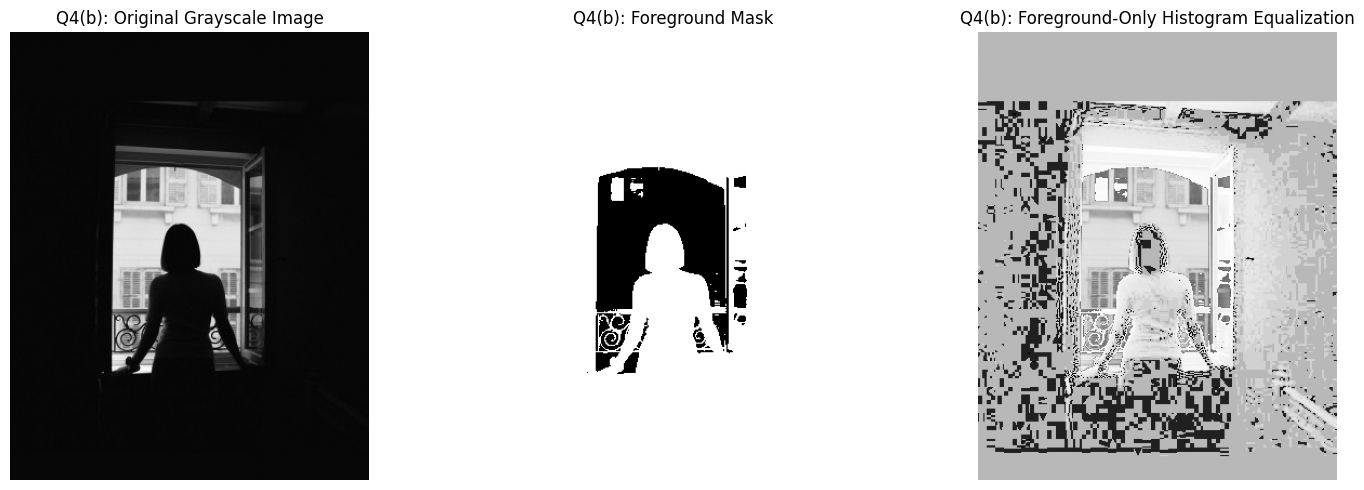

In [22]:
# ===============================
# Q4(b) - Histogram Equalization Only for Foreground
# ===============================

# Convert mask to boolean
mask_bool = foreground_mask > 0

# Copy original grayscale image
img_foreground_eq = img_gray.copy()

# Extract foreground pixels only
foreground_pixels = img_gray[mask_bool]

# Manual histogram equalization function for selected region
def equalize_region(pixels):
    if len(pixels) == 0:
        return pixels, np.zeros(256, dtype=int), np.zeros(256), np.arange(256, dtype=np.uint8)

    hist, _ = np.histogram(pixels, bins=256, range=[0, 256])
    pdf = hist / len(pixels)
    cdf = np.cumsum(pdf)
    transform = np.floor(255 * cdf).astype(np.uint8)
    equalized_pixels = transform[pixels]

    return equalized_pixels, hist, cdf, transform

# Equalize only the foreground region
equalized_pixels, hist_fg, cdf_fg, transform_fg = equalize_region(foreground_pixels)

# Put equalized foreground pixels back into image
img_foreground_eq[mask_bool] = equalized_pixels

# Display Q4(b) results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Q4(b): Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(foreground_mask, cmap='gray')
plt.title('Q4(b): Foreground Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_foreground_eq, cmap='gray')
plt.title('Q4(b): Foreground-Only Histogram Equalization')
plt.axis('off')

plt.tight_layout()
plt.show()

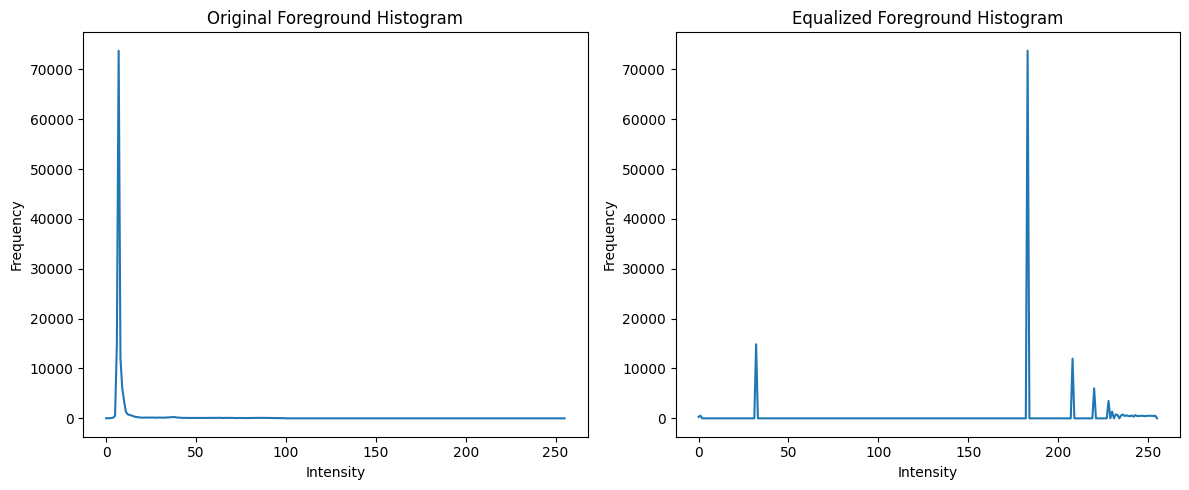

In [23]:
# ===============================
#  histogram comparison for foreground region
# ===============================

hist_eq_fg, _ = np.histogram(img_foreground_eq[mask_bool], bins=256, range=[0, 256])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_fg)
plt.title('Original Foreground Histogram')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.plot(hist_eq_fg)
plt.title('Equalized Foreground Histogram')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Q4(a): The image was converted to grayscale and Otsu thresholding was applied to separate the dark foreground from the bright background. The threshold value selected by Otsu’s method was approximately X. Since the woman and room were darker than the exterior region, the binary result was inverted to obtain the foreground mask.

#### Q4(b): Histogram equalization was then applied only to the foreground region defined by the mask. This improved the visibility of dark areas in the room while keeping the already bright exterior unchanged. As a result, hidden details such as the outline of the woman, window frame, railing, and shadow variations became clearer.